In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd

In [4]:
df = pd.read_csv("dataset/train.csv")

In [5]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
df.shape

(1460, 81)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [8]:
missing = df.isnull().sum()
missing = missing[missing > 0]
missing.sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64

In [9]:
numeric_df = df.select_dtypes(include=["number"])

corr = numeric_df.corr()

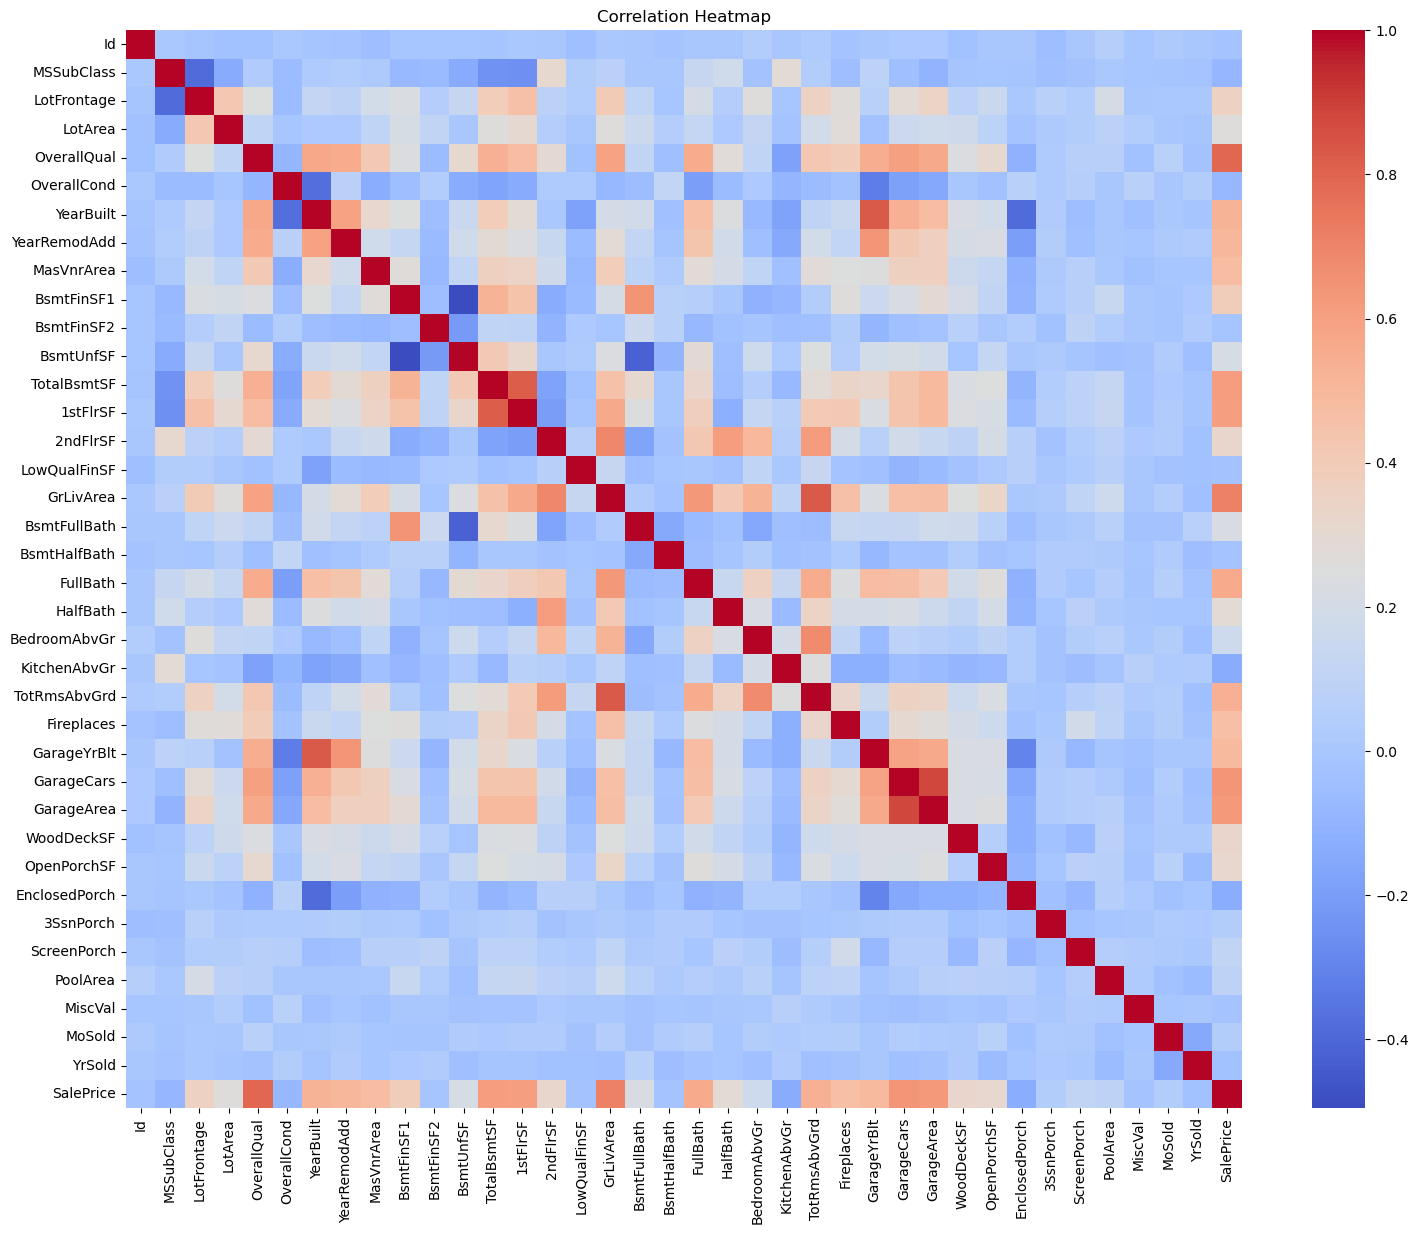

In [10]:
plt.figure(figsize=(18,14))

sns.heatmap(corr, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [11]:
corr["SalePrice"].sort_values(ascending=False).head(15)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

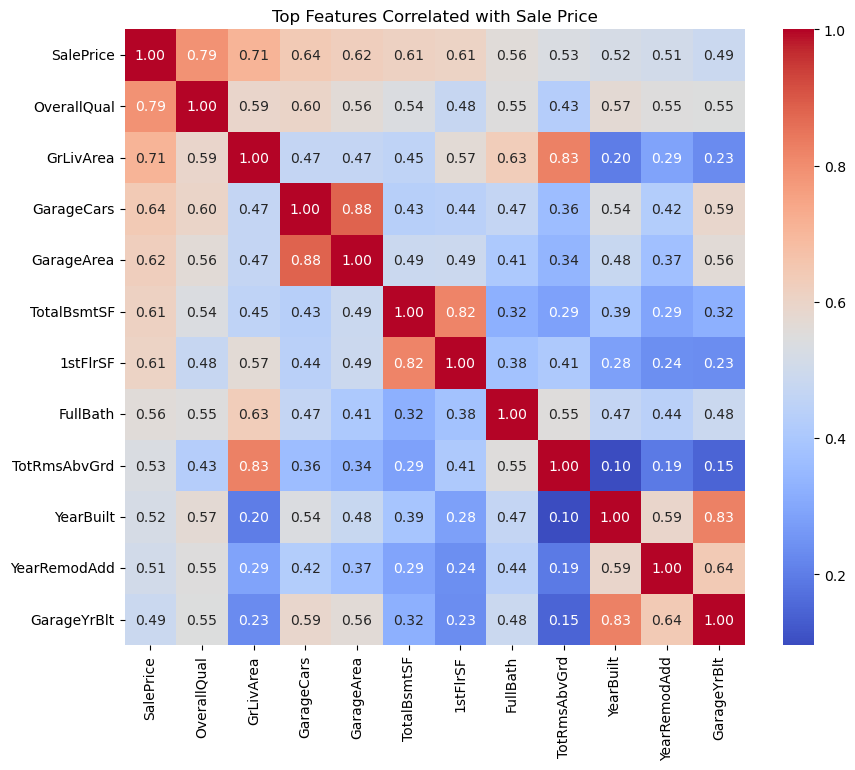

In [12]:
top_features = corr["SalePrice"].abs().sort_values(ascending=False).head(12).index

plt.figure(figsize=(10,8))

sns.heatmap(
    corr.loc[top_features, top_features],
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Top Features Correlated with Sale Price")

plt.show()

In [13]:
df = df.drop("Id", axis=1)

X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

In [14]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns

categorical_features = X.select_dtypes(include=["object"]).columns

print("Numeric Features:", len(numeric_features))
print("Categorical Features:", len(categorical_features))

Numeric Features: 36
Categorical Features: 43


In [15]:
print("Numeric Features:", len(numeric_features))
print("Categorical Features:", len(categorical_features))

Numeric Features: 36
Categorical Features: 43


In [16]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

In [17]:
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [18]:
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set: (1168, 79)
Testing Set : (292, 79)


In [20]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

In [21]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [22]:
y_pred = model.predict(X_test)

In [23]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R² Score : {r2:.4f}")

MSE  : 980045047.32
RMSE : 31305.67
R² Score : 0.8722


In [24]:
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R² Score : {r2:.4f}")

MSE  : 980045047.32
RMSE : 31305.67
R² Score : 0.8722


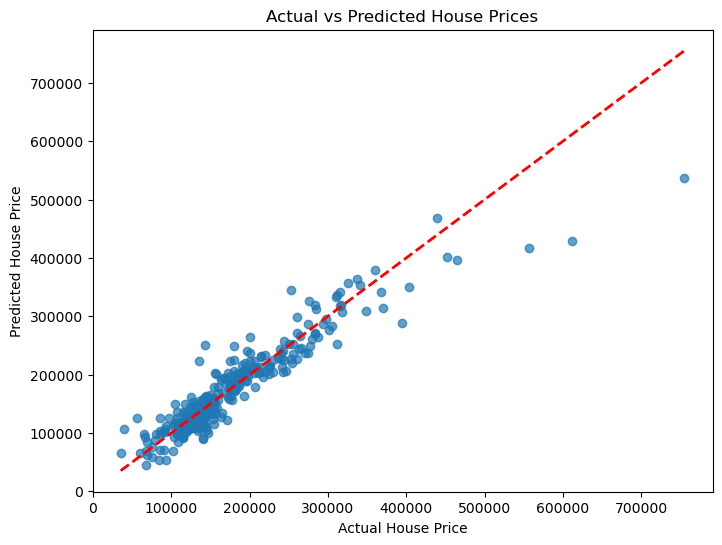

In [25]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--',
    linewidth=2
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

Interpretation

The scatter plot compares the actual house prices with the predicted prices. Points closer to the red diagonal line indicate more accurate predictions. Since most observations lie close to the line, the Linear Regression model demonstrates good predictive performance.

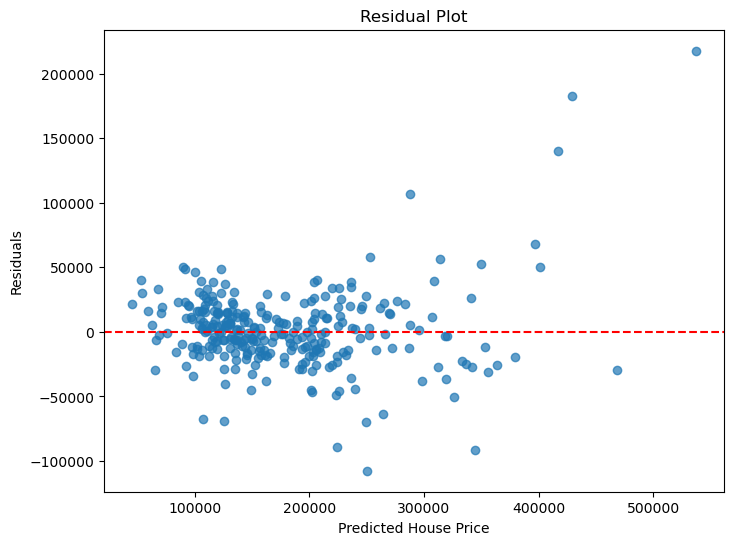

In [26]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals, alpha=0.7)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted House Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

Interpretation

Residuals are randomly scattered around zero, indicating that the model captures the overall linear relationship well. No strong systematic pattern is observed, suggesting that the assumptions of Linear Regression are reasonably satisfied.

In [27]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

coefficients = model.named_steps["regressor"].coef_

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df = coef_df.sort_values(by="Coefficient", ascending=False)

coef_df.head(15)

,Feature,Coefficient
78,cat__Neighborhood_NoRidge,41894.370269
85,cat__Neighborhood_StoneBr,39119.060868
259,cat__PoolQC_Ex,28004.477157
79,cat__Neighborhood_NridgHt,24773.234481
134,cat__Exterior1st_BrkFace,23200.045896
153,cat__Exterior2nd_ImStucc,21419.376027
180,cat__BsmtQual_Ex,20061.024317
221,cat__KitchenQual_Ex,19447.514446
50,cat__LandContour_HLS,18918.798410
69,cat__Neighborhood_Crawfor,16886.389005


In [28]:
coef_df.tail(15)

,Feature,Coefficient
247,cat__GarageQual_Fa,-11510.998909
63,cat__Neighborhood_Blmngtn,-11954.406163
142,cat__Exterior1st_Stucco,-12008.532918
57,cat__LotConfig_FR2,-12526.681692
115,cat__HouseStyle_2Story,-12783.819346
75,cat__Neighborhood_NAmes,-13055.404184
77,cat__Neighborhood_NWAmes,-14291.636711
71,cat__Neighborhood_Gilbert,-14892.531463
47,cat__LotShape_IR3,-15407.352755
70,cat__Neighborhood_Edwards,-17223.658914


Coefficient Analysis

Positive coefficients indicate that an increase in the corresponding feature increases the predicted house price, while negative coefficients decrease the predicted price. Features with larger absolute coefficients have a stronger influence on the model's predictions.

In [29]:
ridge_model = Pipeline([
    ("preprocessor", preprocessor),
    ("ridge", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

print(f"Ridge MSE  : {ridge_mse:.2f}")
print(f"Ridge RMSE : {ridge_rmse:.2f}")
print(f"Ridge R²   : {ridge_r2:.4f}")

Ridge MSE  : 1194183824.82
Ridge RMSE : 34556.96
Ridge R²   : 0.8443


In [30]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "RMSE": [rmse, ridge_rmse],
    "R² Score": [r2, ridge_r2]
})

comparison

,Model,RMSE,R² Score
0,Linear Regression,31305.671169,0.872229
1,Ridge Regression,34556.964925,0.844311
